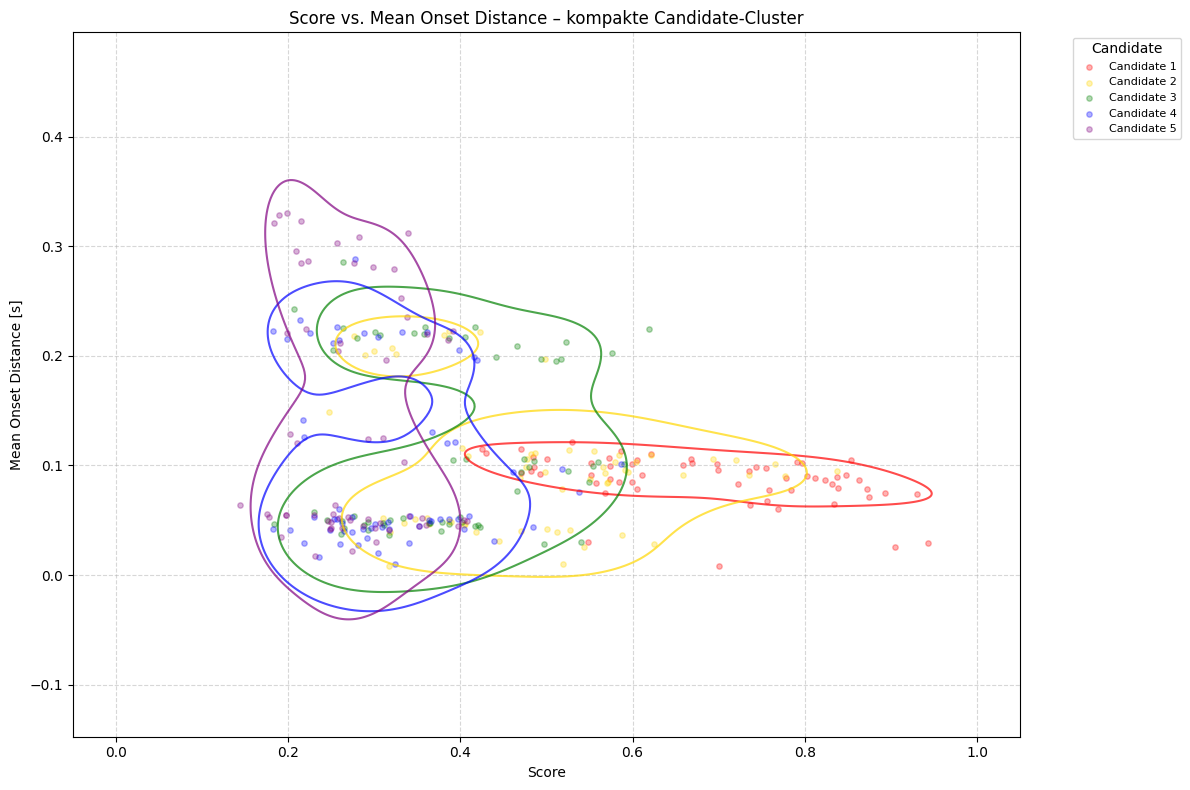

Winner-Candidate-Tabelle gespeichert unter: /Users/emilschmiedl/Desktop/winner_candidate_counts.csv


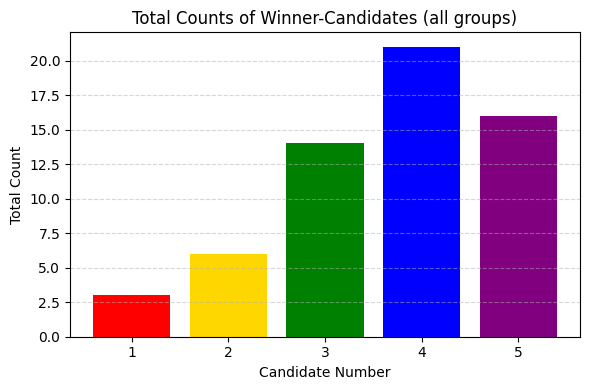

Barplot gespeichert unter: /Users/emilschmiedl/Desktop/winner_candidate_barplot.png


In [13]:
# === Score vs. Mean Onset Distance – kompakte Candidate-Cluster ===
# Dieses Skript analysiert Beat-Kandidaten aus Test-Sequenzen und visualisiert
# die Beziehung zwischen Score und mittlerer Onset-Distanz.
# Es verwendet die Proximity-Funktion, um geeignete Beats zu identifizieren.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# === Hilfsfunktionen ===
def generate_beat_candidates_from_iois(iois, min_ioi=0.05, max_ioi=6.0, resolution=0.01, max_denominator=48):
    raster = np.arange(min_ioi, max_ioi + 1e-12, resolution)
    candidates = set(np.round(raster, 6))
    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(float(Fraction(beat).limit_denominator(1000)))
    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(float(Fraction(val).limit_denominator(1000)))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

# === Hauptlogik ===
def compute_beat_candidates_dataframe(filename, onsets, iois, params, top_n=5):
    # 1) Beat-Kandidaten berechnen
    beat_candidates = generate_beat_candidates_from_iois(iois)
    scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
    local_maxima = find_local_maxima(beat_candidates, scores, order=2)
    local_maxima_top = sorted(local_maxima, key=lambda x: -x[1])[:top_n]

    # 2) Ergebnisse in DataFrame speichern
    rows = []
    for idx, (beat, score) in enumerate(local_maxima_top, start=1):
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        rows.append({
            "filename": filename,
            "candidate_number": idx,
            "score": score,
            "mean_onset_distance": stats["mean_onset_dist"]
        })
    df = pd.DataFrame(rows)
    return df

# Parameter für proximity_max_freq
params = {
    "sharpness_base": 10.0,
    "sharpness_growth": 2.0,
    "decay": 0.1,
    "max_freq": 5,
    "weight_exponent": 1.0,
    "freq_sharpness_exp": 1.0,
    "norm_x": 1.0,
    "output_max": 1.0
}

# Ordner, in dem die CSV-Dateien liegen
folder = Path("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)")

# Alle CSV-Dateien im Ordner
csv_files = list(folder.glob("*.csv"))

# Liste der Präfixe, die du analysieren willst
#selected_prefixes = ["jitter"]  # z. B. alles, was mit "group1_" oder "group2_" beginnt

all_rows = []

for file in csv_files:
    df_csv = pd.read_csv(file)
    onsets = df_csv['onset'].values
    iois = np.diff(onsets)

    df_beats = compute_beat_candidates_dataframe(file.name, onsets, iois, params, top_n=5)

    # filename_group erstellen (alles vor dem letzten Unterstrich)
    filename_stem = file.stem
    filename_group = "_".join(filename_stem.split("_")[:-1])
    df_beats['filename_group'] = filename_group

    all_rows.append(df_beats)

# Alle Ergebnisse zusammenführen
df_all = pd.concat(all_rows, ignore_index=True)

# Plot nach Candidate-Nummer
plt.figure(figsize=(12, 8))

# Eigene Farbpalette (kräftige Farben)
colors = [
    "red", "gold", "green", "blue", "purple",
]

for i, cand_num in enumerate(sorted(df_all['candidate_number'].unique())):
    subset = df_all[df_all['candidate_number'] == cand_num]
    
    if len(subset) < 2:
        continue  # KDE braucht mindestens 2 Punkte
    
    sns.kdeplot(
        x=subset['score'],
        y=subset['mean_onset_distance'],
        fill=False,         
        alpha=0.7,
        color=colors[i],
        levels=2,          # min. 2 Levels, wirkt fast wie eine einzige Fläche
        thresh=0.3         # nur dichten Kern zeigen
    )
    
    plt.scatter(
        subset['score'],
        subset['mean_onset_distance'],
        color=colors[i],
        s=15,
        alpha=0.3
    )

plt.xlabel("Score")
plt.xlim(-0.05, 1.05)
plt.ylabel("Mean Onset Distance [s]")
plt.title("Score vs. Mean Onset Distance – kompakte Candidate-Cluster")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend([f"Candidate {n}" for n in sorted(df_all['candidate_number'].unique())],
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title="Candidate")

plt.tight_layout()
plt.savefig("/Users/emilschmiedl/Desktop/mean_onset_distance_clusters_compact.png", dpi=300)
plt.show()

# === Nachbearbeitung: Winner-Candidate zählen ===
winner_rows = []

for group_name, group_df in df_all.groupby("filename_group"):
    # Pro Datei den Candidate mit kleinstem mean_onset_distance ermitteln
    best_per_file = group_df.loc[group_df.groupby("filename")["mean_onset_distance"].idxmin()]
    
    # Counts der Gewinner-Candidates
    counts = best_per_file["candidate_number"].value_counts().sort_index()
    
    # Immer 5 Zeilen erzeugen, auch wenn ein Candidate nicht vorkam
    for cand in range(1, 6):
        count_val = counts.get(cand, 0)
        winner_rows.append({
            "filename_group": group_name,
            "candidate_number": cand,
            "count": count_val
        })

df_winners = pd.DataFrame(winner_rows)

# CSV speichern
output_csv = Path("/Users/emilschmiedl/Desktop/winner_candidate_counts.csv")
df_winners.to_csv(output_csv, index=False)
print(f"Winner-Candidate-Tabelle gespeichert unter: {output_csv}")

# === Gesamt-Counts über alle Gruppen ===
total_counts = df_winners.groupby("candidate_number")["count"].sum().reset_index()

# Barplot
plt.figure(figsize=(6, 4))
plt.bar(total_counts["candidate_number"], total_counts["count"], color=["red", "gold", "green", "blue", "purple"])
plt.xticks(total_counts["candidate_number"])
plt.xlabel("Candidate Number")
plt.ylabel("Total Count")
plt.title("Total Counts of Winner-Candidates (all groups)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Speichern
barplot_path = Path("/Users/emilschmiedl/Desktop/winner_candidate_barplot.png")
plt.tight_layout()
plt.savefig(barplot_path, dpi=300)
plt.show()

print(f"Barplot gespeichert unter: {barplot_path}")

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_1335/299720285.py:41: RuntimeWarning: invalid value encountered in power
  denom = np.where(x == 0, 1e-12, x ** decay)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_1335/299720285.py:41: RuntimeWarning: invalid value encountered in power
  denom = np.where(x == 0, 1e-12, x ** decay)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_1335/299720285.py:41: RuntimeWarning: invalid value encountered in power
  denom = np.where(x == 0, 1e-12, x ** decay)


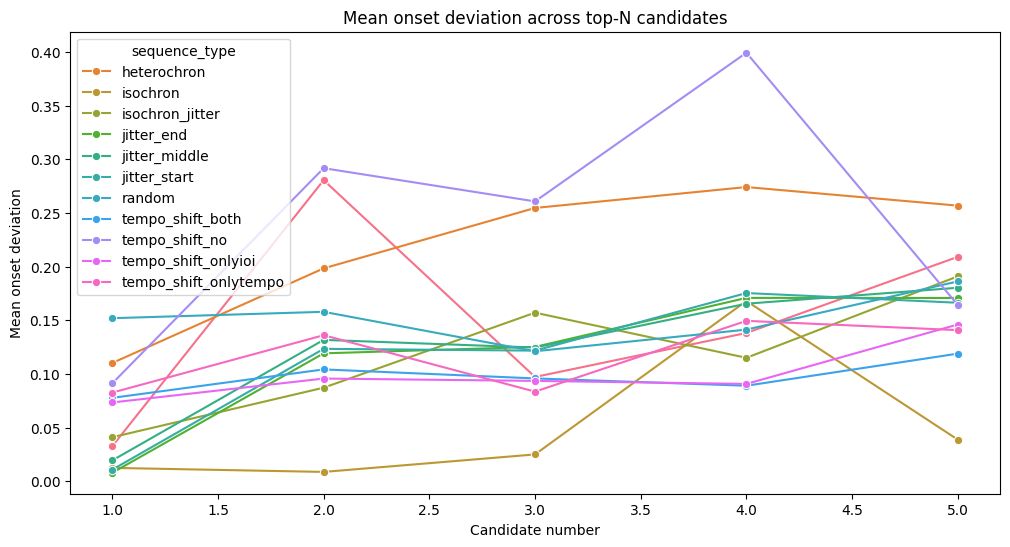

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# === Hilfsfunktionen ===
def generate_beat_candidates_from_iois(iois, min_ioi=0.05, max_ioi=6.0, resolution=0.01, max_denominator=48):
    raster = np.arange(min_ioi, max_ioi + 1e-12, resolution)
    candidates = set(np.round(raster, 6))
    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(float(Fraction(beat).limit_denominator(1000)))
    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(float(Fraction(val).limit_denominator(1000)))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

# === Hauptlogik ===
def compute_beat_candidates_dataframe(filename, onsets, iois, params, top_n=5):
    # 1) Beat-Kandidaten berechnen
    beat_candidates = generate_beat_candidates_from_iois(iois)
    scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
    local_maxima = find_local_maxima(beat_candidates, scores, order=2)
    local_maxima_top = sorted(local_maxima, key=lambda x: -x[1])[:top_n]

    # 2) Ergebnisse in DataFrame speichern
    rows = []
    for idx, (beat, score) in enumerate(local_maxima_top, start=1):
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        rows.append({
            "filename": filename,
            "candidate_number": idx,
            "score": score,
            "mean_onset_distance": stats["mean_onset_dist"]
        })
    df = pd.DataFrame(rows)
    return df

# Parameter für proximity_max_freq
params = {
    "sharpness_base": 10.0,
    "sharpness_growth": 2.0,
    "decay": 0.1,
    "max_freq": 4,
    "weight_exponent": 1.0,
    "freq_sharpness_exp": 1.0,
    "norm_x": 1.0,
    "output_max": 1.0
}

# Ordner, in dem die CSV-Dateien liegen
folder = Path("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats")

# Alle CSV-Dateien im Ordner
csv_files = list(folder.glob("*.csv"))

# Liste der Präfixe, die du analysieren willst
#selected_prefixes = ["jitter"]  # z. B. alles, was mit "group1_" oder "group2_" beginnt

all_rows = []

for file in csv_files:
    df_csv = pd.read_csv(file)
    onsets = df_csv['onset'].values
    iois = np.diff(onsets)

    df_beats = compute_beat_candidates_dataframe(file.name, onsets, iois, params, top_n=5)

    # filename_group erstellen (alles vor dem letzten Unterstrich)
    filename_stem = file.stem
    filename_group = "_".join(filename_stem.split("_")[:-1])
    df_beats['filename_group'] = filename_group

    all_rows.append(df_beats)

# Alle Ergebnisse zusammenführen
df_all = pd.concat(all_rows, ignore_index=True)
df_all['sequence_type'] = df_all['filename_group'].apply(lambda x: x.split('-')[0] if '-' in x else x)
df_best = df_all[df_all['candidate_number'] == 1]

# Top-N Vergleich (Candidate 1–5) pro Sequenztyp
top_n_stats = df_all.groupby(['sequence_type','candidate_number'])['mean_onset_distance'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='candidate_number', y='mean_onset_distance', hue='sequence_type', 
             data=top_n_stats, marker='o')
plt.title("Mean onset deviation across top-N candidates")
plt.xlabel("Candidate number")
plt.ylabel("Mean onset deviation")
plt.show()

